In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fx = pd.read_csv('data_safe_copy.csv', parse_dates=['Date'], index_col='Date')

In [3]:
fx.sort_index(ascending=True, inplace=True)

In [4]:
print("Is index sorted in ascending order?", fx.index.is_monotonic_increasing)

Is index sorted in ascending order? True


In [5]:
fx = fx.apply(pd.to_numeric, errors='coerce')

In [6]:
fx.head()

,EURUSD,GBPUSD,PLNUSD,USDPLN,USDJPY,AUDUSD,NZDUSD,USDCAD,USDCHF,EURPLN,GBPPLN
Date,,,,,,,,,,,
2025-01-02,1.02661,1.23826,0.240270,4.16199,157.4610,0.62033,0.55966,1.44067,0.91210,4.27274,5.15363
2025-01-03,1.03062,1.24267,0.241453,4.14160,157.3420,0.62176,0.56089,1.44467,0.90891,4.26841,5.14664
2025-01-06,1.03900,1.25188,0.244290,4.09350,157.6200,0.62427,0.56402,1.43330,0.90478,4.25315,5.12457
2025-01-07,1.03426,1.24771,0.242804,4.11855,158.0405,0.62326,0.56331,1.43683,0.90937,4.25965,5.13875
2025-01-08,1.03185,1.23638,0.241377,4.14290,158.3085,0.62132,0.56058,1.43758,0.91101,4.27485,5.12220


In [7]:
fx.tail()

,EURUSD,GBPUSD,PLNUSD,USDPLN,USDJPY,AUDUSD,NZDUSD,USDCAD,USDCHF,EURPLN,GBPPLN
Date,,,,,,,,,,,
2026-01-26,1.18777,1.36768,0.282362,3.54155,154.1550,0.69100,0.59697,1.37115,0.77720,4.20655,4.84370
2026-01-27,1.20426,1.38461,0.286789,3.48689,152.3020,0.70092,0.60433,1.35758,0.76114,4.19912,4.82798
2026-01-28,1.19562,1.38024,0.284316,3.51721,153.4235,0.70384,0.60594,1.35621,0.76859,4.20524,4.85459
2026-01-29,1.19695,1.38095,0.284600,3.51370,153.0050,0.70497,0.60751,1.34872,0.76476,4.20572,4.85224
2026-01-30,1.18534,1.36839,0.281465,3.55284,154.7785,0.69637,0.60212,1.36162,0.77302,4.21132,4.86167


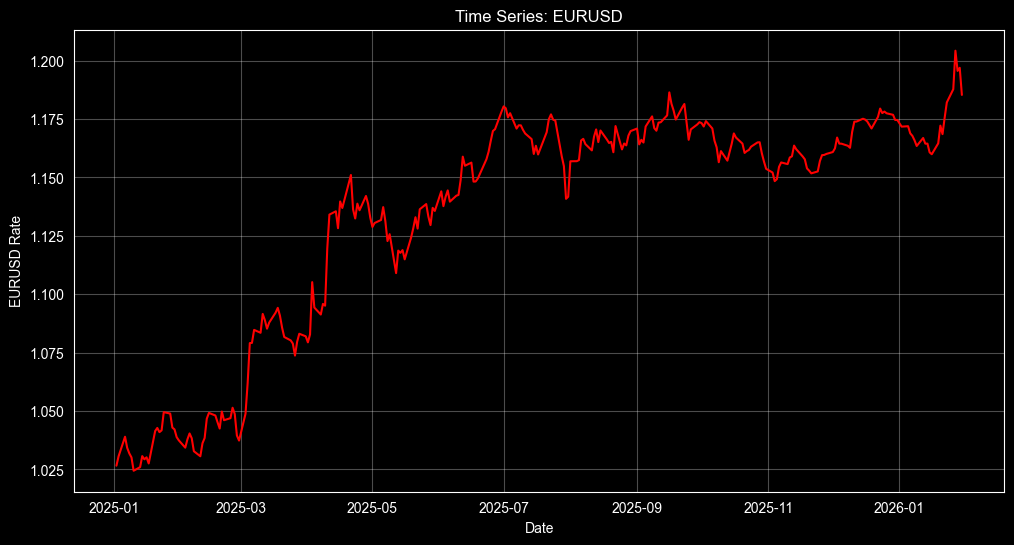

In [8]:
eur_usd = fx['EURUSD']
usd_pln = fx['USDPLN']

plt.figure(figsize=(12, 6))
plt.plot(fx.index, eur_usd, color='red')
plt.title(f'Time Series: EURUSD')
plt.xlabel('Date')
plt.ylabel('EURUSD Rate')
plt.grid(True, alpha=0.3)
plt.show()

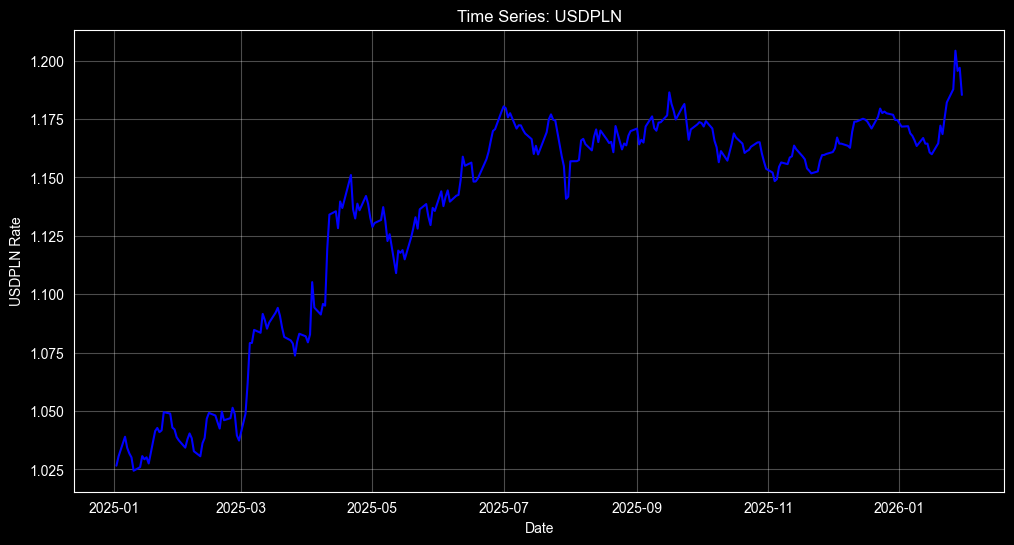

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(fx.index, eur_usd, color='blue')
plt.title(f'Time Series: USDPLN')
plt.xlabel('Date')
plt.ylabel('USDPLN Rate')
plt.grid(True, alpha=0.3)
plt.show()

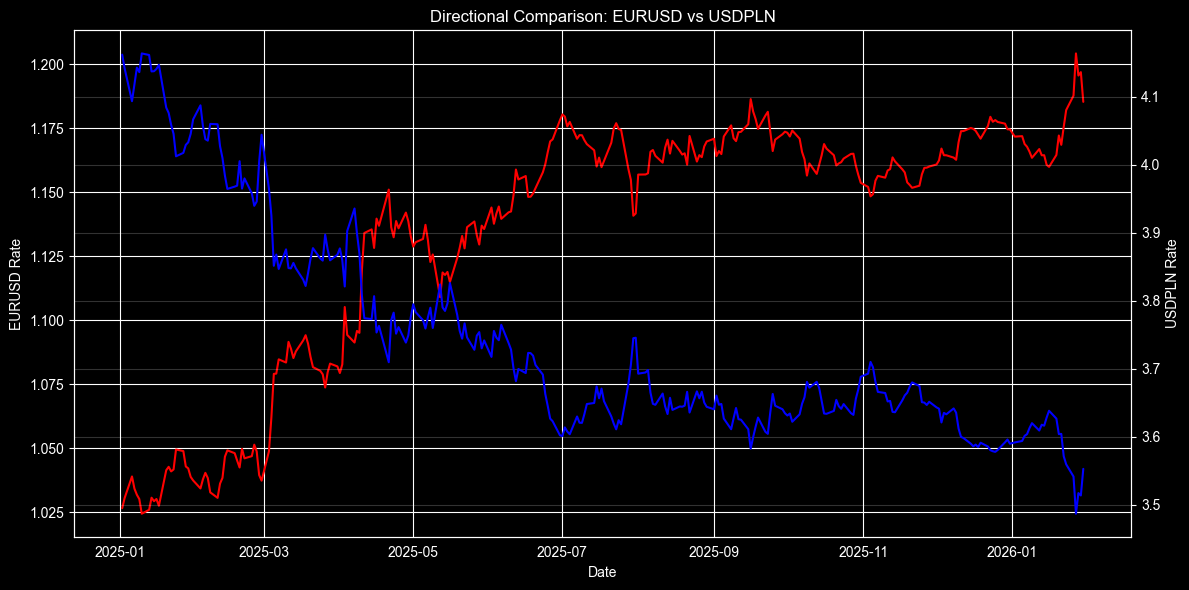

In [10]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel("Date")
ax1.set_ylabel('EURUSD Rate')
ax1.plot(fx.index, eur_usd, color='red', label='EURUSD')

ax2 = ax1.twinx()
ax2.set_ylabel('USDPLN Rate')
ax2.plot(fx.index, usd_pln, color='blue', label='USDPLN')

plt.title('Directional Comparison: EURUSD vs USDPLN')
fig.tight_layout()
plt.grid(True, alpha=0.2)
plt.show()

In [11]:
eurusd_mean_7d = fx['EURUSD'].rolling(window=7).mean()
usdpln_mean_7d = fx['USDPLN'].rolling(window=7).mean()

In [12]:
eurusd_std_7d = fx['EURUSD'].rolling(window=7).std()
usdpln_std_7d = fx['USDPLN'].rolling(window=7).std()

In [13]:
rolling_results = pd.DataFrame({
    'EURUSD': fx['EURUSD'],
    'EURUSD_Mean_7d': eurusd_mean_7d,
    'EURUSD_Std_7d': eurusd_std_7d,
    'USDPLN': fx['USDPLN'],
    'USDPLN_Mean_7d': usdpln_mean_7d,
    'USDPLN_Std_7d': usdpln_std_7d
})

In [14]:
rolling_results.head(10)

,EURUSD,EURUSD_Mean_7d,EURUSD_Std_7d,USDPLN,USDPLN_Mean_7d,USDPLN_Std_7d
Date,,,,,,
2025-01-02,1.02661,NaN,NaN,4.16199,NaN,NaN
2025-01-03,1.03062,NaN,NaN,4.14160,NaN,NaN
2025-01-06,1.03900,NaN,NaN,4.09350,NaN,NaN
2025-01-07,1.03426,NaN,NaN,4.11855,NaN,NaN
2025-01-08,1.03185,NaN,NaN,4.14290,NaN,NaN
2025-01-09,1.03015,NaN,NaN,4.13630,NaN,NaN
2025-01-10,1.02445,1.030991,0.004803,4.16379,4.136947,0.024601
2025-01-13,1.02597,1.030900,0.004905,4.16150,4.136877,0.024519
2025-01-14,1.03070,1.030911,0.004904,4.13735,4.136270,0.024435


In [18]:
print(f"Missing Value Counts: \n{rolling_results[['EURUSD_Mean_7d', 'USDPLN_Mean_7d']].isna().sum()}")

null_after_start = rolling_results.iloc[7:].isna().any().any()
print(f"\nAre there missing values after the initial window? {null_after_start}")

Missing Value Counts: 
EURUSD_Mean_7d    6
USDPLN_Mean_7d    6
dtype: int64

Are there missing values after the initial window? False


In [23]:
pair = 'EURUSD'
fx['baseline_pred'] = fx[pair].shift(1)
fx['abs_error'] = (fx[pair] - fx['baseline_pred']).abs()

In [24]:
mae = fx['abs_error'].mean()
print(f"Baseline Mean Absolute Error for {pair}: {mae:.5f}")

Baseline Mean Absolute Error for EURUSD: 0.00407


In [25]:
total_rows = len(fx)
non_missing_preds = fx['baseline_pred'].notna().sum()

print(f"\nTotal rows in dataset: {total_rows}")
print(f"Number of non-missing predictions: {non_missing_preds}")
print(f'Validation: {total_rows -1 == non_missing_preds}')


Total rows in dataset: 280
Number of non-missing predictions: 279
Validation: True


In [34]:
chosen_pairs = ['EURUSD', 'USDPLN']
rolling_window = 7
date_start = fx.index.min().strftime('%Y-%m-%d')
date_end = fx.index.max().strftime('%Y-%m-%d')

report = {
    "Selected Pairs": chosen_pairs,
    "Rolling Window Size": rolling_window,
    "Baseline MAE": round(mae, 5),
    "Time Span": f"{date_start} to {date_end}"
}

print("FX Analysis Report\n")
for key, value in report.items():
    print(f"{key}: {value}")

real_window_size = rolling_results['EURUSD_Mean_7d'].isna().sum() + 1
print(f"\nValidation:\n{real_window_size == report['Rolling Window Size']}")

FX Analysis Report

Selected Pairs: ['EURUSD', 'USDPLN']
Rolling Window Size: 7
Baseline MAE: 0.00407
Time Span: 2025-01-02 to 2026-01-30

Validation:
True
